## 1. Import Library

In [6]:
import sys
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from IPython.display import display

Tahap pertama yang kita lakukan adalah memanggil semua *library* pendukung yang dibutuhkan dalam proses pengolahan citra dan klasifikasi. Di sini kita menggunakan `cv2` (OpenCV) dan `skimage` untuk mengolah gambar dan mengekstrak fitur teksturnya. Untuk perhitungan matriks, kita memakai `numpy`, sedangkan `pandas` akan kita gunakan untuk menyusun hasil ekstraksi menjadi tabel data yang rapi. Selain itu, kita juga mengimpor algoritma *Machine Learning* seperti Random Forest, SVM, dan KNN dari `scikit-learn` beserta alat ukur akurasinya. Terakhir, `matplotlib` dan `seaborn` disiapkan untuk menampilkan visualisasi grafik.

## 2. Load Dataset

Langkah selanjutnya adalah memuat gambar dataset ke dalam memori program. Kode di bawah ini akan membuka folder `dataset` dan membaca setiap sub-folder di dalamnya. Nama dari sub-folder tersebut otomatis dijadikan sebagai label kelas (misalnya, daun dengan *Black Rot* atau daun sehat). Setiap gambar yang berhasil dibaca akan disimpan dalam *array* `data`, dan labelnya disimpan dalam *array* `labels`. Jika ada gambar yang rusak, sistem akan otomatis melewatinya. Output di bawah ini akan menampilkan total gambar yang berhasil dimuat beserta daftar kelas yang ditemukan, untuk memastikan semua data sudah masuk dengan benar.

In [7]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_path = os.path.join("dataset", sub_folder)
    if os.path.isdir(sub_folder_path):
        for i, filename in enumerate(os.listdir(sub_folder_path)):
            img_path = os.path.join(sub_folder_path, filename)
            img = cv.imread(img_path)

            if img is None:
                continue

            data.append(img)
            labels.append(sub_folder)
            file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total gambar yang dimuat: {len(data)}")
print(f"Daftar kelas yang ditemukan: {sorted(set(labels))}")

Total gambar yang dimuat: 200
Daftar kelas yang ditemukan: ['Grape_black_rot_100', 'daun_sehat_100']


## 3. Definisi Pipeline Preprocessing

In [8]:
TARGET_SIZE = (256, 256)

def gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray_img = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray_img = resized
    return gray_img.astype(np.uint8)

def median(image_input, kernel_size=5):
    img = image_input.copy()
    pad_size = kernel_size // 2
    padded = np.pad(img, pad_size, mode='constant')
    height, width = img.shape
    K = kernel_size * kernel_size

    windows = np.zeros((K, height, width), dtype=np.uint8)
    idx = 0
    for di in range(kernel_size):
        for dj in range(kernel_size):
            windows[idx] = padded[di:di+height, dj:dj+width]
            idx += 1

    half = (K + 1) // 2
    cum_count = np.zeros((height, width), dtype=np.int32)
    median_result = np.zeros((height, width), dtype=np.uint8)
    selesai = np.zeros((height, width), dtype=bool)

    for v in range(256):
        count_v = np.sum(windows == v, axis=0)
        cum_count = cum_count + count_v
        baru_capai = (cum_count >= half) & (~selesai)
        median_result[baru_capai] = v
        selesai = selesai | baru_capai

    return median_result.astype(np.uint8)

def histogram_equalization(image_input):
    img = image_input.copy()
    L = 256
    counts, _ = np.histogram(img, bins=L, range=(0, L))
    cdf = np.cumsum(counts)

    cdf_min = np.min(cdf[cdf > 0])
    total_pixel = np.sum(counts)

    mapping = np.round((cdf - cdf_min) / (total_pixel - cdf_min) * (L - 1))
    mapping = np.clip(mapping, 0, L - 1)
    return mapping[img].astype(np.uint8)

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

sobelX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobelY = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)
robertsX = np.array([[1, 0], [0, -1]], dtype=np.float32)
robertsY = np.array([[0, 1], [-1, 0]], dtype=np.float32)

def prepro(image):
    img1 = gray(image)
    img2 = median(img1)
    img3 = histogram_equalization(img2)
    img4 = edge(img3, sobelX, sobelY)
    img5 = edge(img4, robertsX, robertsY)
    return img1, img2, img3, img4, img5

def run_prepro(image):
    _, _, _, _, final_img = prepro(image)
    return final_img

Sebelum mulai mengambil ciri atau fitur dari daun, gambar mentah perlu melalui proses *preprocessing*. Tujuannya agar informasi tekstur dan bentuk tepi daun menjadi lebih jelas, sementara *noise* (gangguan kecil pada gambar) bisa dikurangi. Pada blok kode di atas, kita merangkai beberapa tahap secara berurutan:
1. `gray`: Mengubah ukuran gambar menjadi standar 256x256 piksel dan membuang warna aslinya menjadi hitam-putih (*Grayscale*), agar sistem lebih fokus pada analisis tekstur.
2. `median`: Menggunakan *Median Filter* untuk menghaluskan gambar dan mengurangi *noise* tanpa merusak bentuk batas asli dari objek daun.
3. `histogram_equalization`: Meratakan kontras gambar sehingga perbedaan antara bagian yang terang dan gelap menjadi jauh lebih tegas.
4. `convolution` dan `edge`: Menggunakan operator *Sobel* dan *Roberts* untuk mendeteksi tepi gambar, sehingga pola tulang daun dan bercak infeksi penyakit menjadi sangat terlihat menonjol.
Semua tahapan ini kemudian digabungkan dengan rapi ke dalam satu fungsi pemanggil utama bernama `prepro`.

## 4. Visualisasi Hasil Preprocessing

Untuk melihat langsung bagaimana fungsi *preprocessing* bekerja, kita akan mencoba memproses beberapa contoh gambar dari setiap kelas. Kode di bawah ini akan mengambil sampel gambar secara acak dan memprosesnya langkah demi langkah.

Begitu kode dijalankan, akan muncul kumpulan gambar yang menunjukkan proses perubahannya. Mulai dari perubahan ke format abu-abu (*Gray*), penghalusan tekstur (*Median*), penegasan warna (*Equalisasi*), hingga penajaman batas-batas tepi daun menggunakan metode *Sobel* dan *Roberts*. Dari gambar ini, kita bisa melihat dengan jelas bagaimana pola bercak penyakit pada daun yang sakit ditonjolkan menjadi garis-garis yang sangat padat dan kontras jika dibandingkan dengan garis mulus pada daun yang sehat.

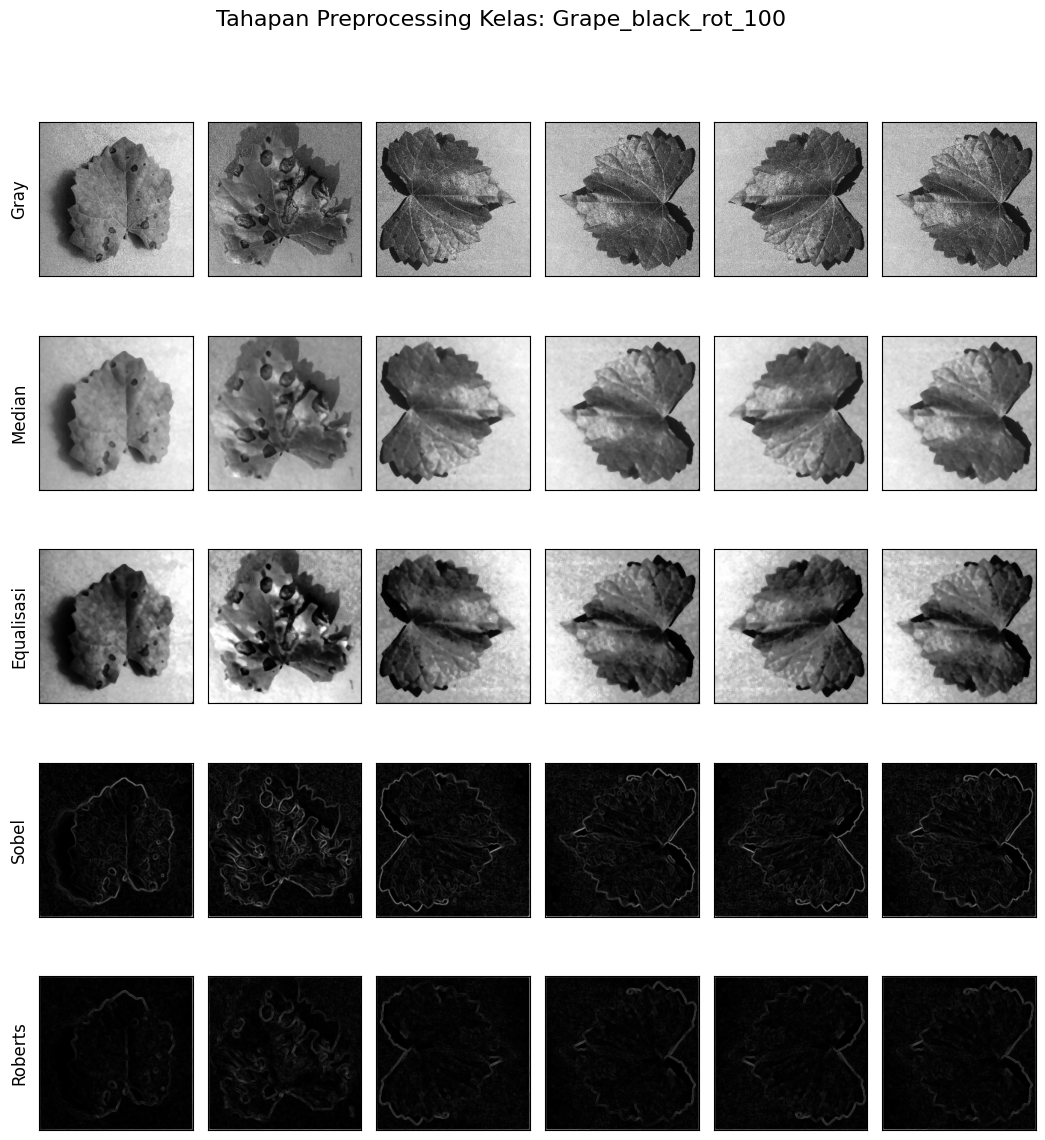

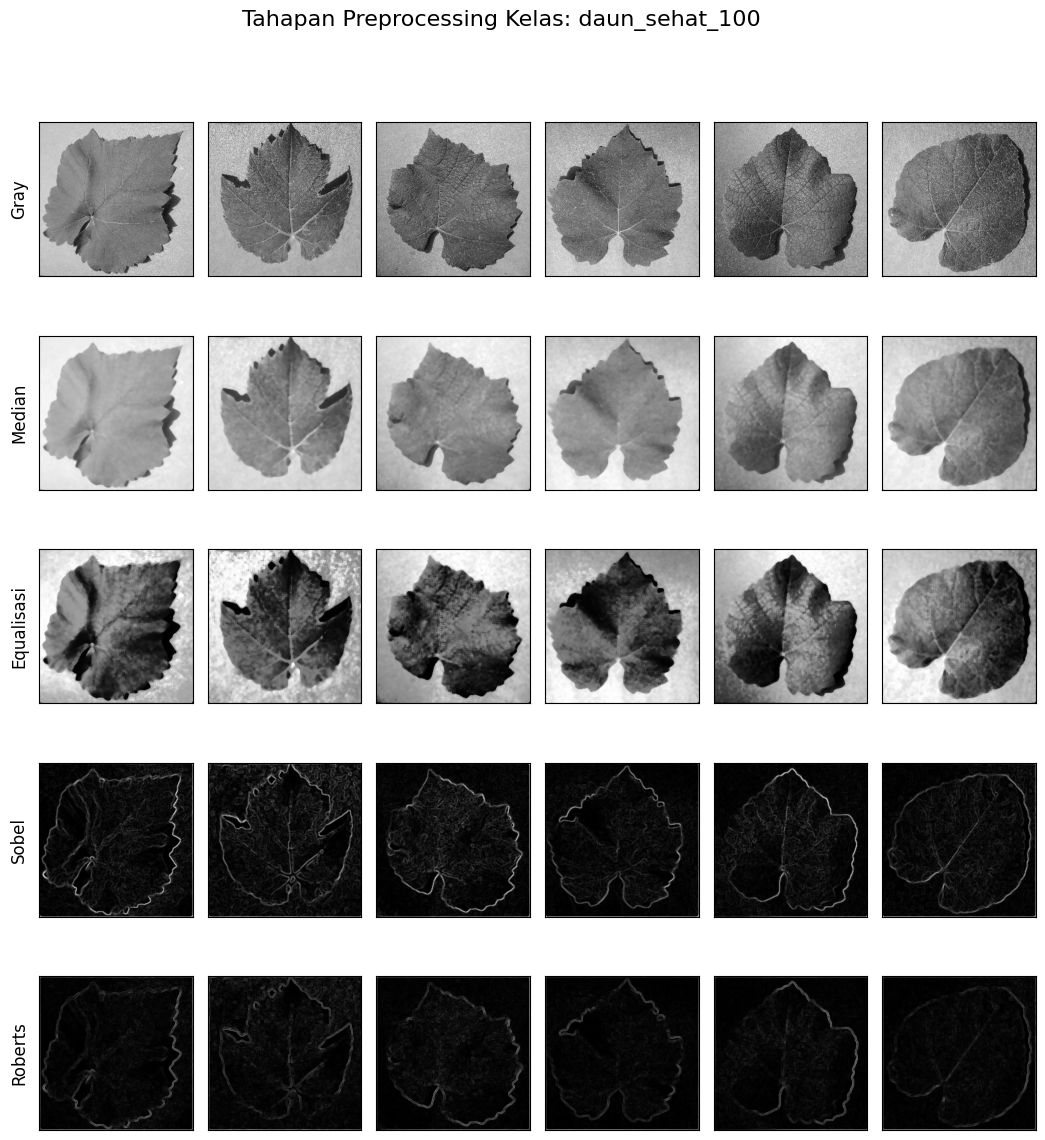

In [9]:
dataPreprocessed = [run_prepro(img) for img in data]
unique_labels = sorted(set(labels))
nama_step = ['Gray', 'Median', 'Equalisasi', 'Sobel', 'Roberts']

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    n_sample = min(6, len(idxs))

    fig, axs = plt.subplots(5, 6, figsize=(11, 12))
    fig.suptitle(f'Tahapan Preprocessing Kelas: {label}', fontsize=16)

    for k in range(n_sample):
        img_asli = data[idxs[k]]
        hasil_tahap = prepro(img_asli)
        
        for row in range(5):
            axs[row][k].imshow(hasil_tahap[row], cmap='gray')
            axs[row][k].set_xticks([])
            axs[row][k].set_yticks([])
            if k == 0:
                axs[row][k].set_ylabel(nama_step[row], fontsize=12, labelpad=8)

    for k in range(n_sample, 6):
        for row in range(5):
            axs[row][k].axis('off')

    plt.tight_layout(rect=[0.04, 0, 1, 1])
    plt.subplots_adjust(top=0.92)
    plt.show()

## 5. Definisi Fungsi Feature Extraction GLCM

In [10]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Angle harus 0, 45, 90, atau 135.")
    
    matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Setelah gambar diproses, kita menggunakan metode *Gray-Level Co-occurrence Matrix* (GLCM) untuk mengekstrak atau mengambil nilai ciri teksturnya secara sistematis. Fungsi `glcm` di atas bertugas membuat matriks yang menghitung seberapa sering dua piksel dengan intensitas warna tertentu muncul secara bersebelahan pada sudut tertentu.

Dari matriks dasar tersebut, kita lalu membuat tujuh fungsi lanjutan untuk mengambil nilai fitur yang spesifik: `Correlation` (mengukur keteraturan pola linier), `Contrast` dan `Dissimilarity` (mengukur perbedaan intensitas atau tingkat kekasaran tekstur), `Homogeneity` (mengukur tingkat kemulusan atau keseragaman gambar), `ASM` dan `Energy` (menilai kestabilan pola secara keseluruhan), serta `Entropy` (mengukur tingkat keacakan pola). Daun yang terkena penyakit seperti *Black Rot* umumnya akan menunjukkan nilai *Entropy* dan *Contrast* yang lebih tinggi karena adanya bercak acak yang merusak susunan alami daun.

## 6. Komputasi Matriks Probabilitas Multi-Sudut

In [11]:
Derajat0, Derajat45, Derajat90, Derajat135 = [], [], [], []

for img in dataPreprocessed:
    Derajat0.append(glcm(img, 0))
    Derajat45.append(glcm(img, 45))
    Derajat90.append(glcm(img, 90))
    Derajat135.append(glcm(img, 135))

Bercak penyakit pada daun bisa muncul dengan arah penyebaran yang tidak beraturan. Jika kita hanya melihat arah tekstur dari satu sudut pandang saja, kita mungkin akan kehilangan banyak informasi penting. Oleh karena itu, blok kode di atas menjalankan proses perhitungan GLCM dari 4 sudut orientasi yang berbeda sekaligus: 0, 45, 90, dan 135 derajat. Hasil matriks dari masing-masing sudut ini kemudian disimpan secara terpisah agar siap diekstrak nilainya pada tahapan selanjutnya.

## 7. Inisialisasi Array Feature Extraction

In [12]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Sebelum memulai penarikan tujuh fitur GLCM dari empat sudut yang berbeda, kita perlu menyiapkan tempat penampungannya. Kode di atas mendeklarasikan 28 daftar (*list*) kosong yang masing-masingnya akan menyimpan hasil perhitungan dari persilangan fitur dan sudut tersebut. Persiapan ini sangat penting agar struktur nilai fitur yang dihasilkan nanti tetap tersusun rapi dan tidak saling tercampur.

## 8. Feature Extraction: Correlation

In [13]:
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

Kode di atas mulai mengekstrak fitur analisis yang pertama, yaitu `Correlation` (Korelasi). Fitur ini bertugas mengukur seberapa teratur hubungan garis antar piksel yang saling berdekatan. Pada spesimen daun yang sehat, nilai korelasi ini biasanya lebih stabil karena pola tulang daunnya terbentuk secara konsisten, utuh, dan alami.

## 9. Feature Extraction: Contrast

In [14]:
for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

Proses ekstraksi dilanjutkan dengan mengambil nilai `Contrast` (Kekontrasan). Fitur eksponensial ini sangat berguna untuk mendeteksi perbedaan intensitas batas yang drastis pada gambar. Kehadiran spot bercak penyakit yang pekat di atas permukaan daun terang akan langsung menghasilkan rekam angka kontras yang tinggi, sehingga mempermudah sistem untuk mengenali ciri daun yang terinfeksi.

## 10. Feature Extraction: Dissimilarity

In [15]:
for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

Selanjutnya kita menarik nilai `Dissimilarity` (Ketidaksamaan). Fungsi dan perannya hampir sama dengan `Contrast` karena ia juga mengukur tingkat perbedaan antar piksel. Namun, karena perhitungannya tidak menggunakan skala kuadrat (lebih linier), fitur ini cenderung lebih fokus dalam menangkap keanekaragaman tekstur kekasaran ringan yang ada pada lesi daun.

## 11. Feature Extraction: Homogeneity

In [16]:
for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

Blok kode di atas menjalankan proses ekstraksi untuk fitur `Homogeneity` (Homogenitas), yang bertujuan mengukur seberapa halus dan seragam permukaan suatu gambar. Daun sehat sebagai kelompok kontrol akan senantiasa memelihara konsistensi integritas permukaannya, yang menyebabkan nilai ekstraksi kemulusan pada fitur ini selalu menempati angka yang jauh lebih tinggi.

## 12. Feature Extraction: Entropy

In [17]:
for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

Pada blok ini, kita melangsungkan pengukuran angka `Entropy` (Entropi). Dalam analisis fitur, ini berfungsi sebagai parameter pengukur tingkat keacakan tekstur (*noise*). Saat jaringan kutikula daun mengalami disrupsi akibat jamur *Black Rot*, kontinuitas warnanya akan hancur acak. Semakin tersebar bercak kerusakan yang ada, maka tingkat entropinya akan melonjak semakin tinggi.

## 13. Feature Extraction: ASM

In [18]:
for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

Pengambilan nilai fitur berikutnya adalah `Angular Second Moment` (ASM). Komputasi metrik ini menargetkan pencarian dominansi tingkat keseragaman pola visual di dalam suatu gambar. Angka ASM yang terekam akan banyak memandu model *Machine Learning* untuk mengevaluasi seberapa tinggi tingkat stabilitas spasial yang ada di dalam spesimen secara keseluruhan.

## 14. Feature Extraction: Energy

In [19]:
for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

Fitur analitis yang terakhir kita operasikan adalah `Energy` (Energi). Properti numerik ini sejatinya diturunkan langsung dari perhitungan akar nilai ASM sebelumnya. Fungsi utamanya adalah untuk menyederhanakan dan memperkecil rentang angka. Pengecilan jarak antar variabel ini sangatlah bermanfaat karena membuat input angka jadi lebih mulus dan bersahabat ketika dikalkulasikan oleh algoritma model pada tahapan berikutnya.

## 15. Pembentukan DataFrame

Setelah seluruh proses ekstraksi rampung, kita memiliki koleksi 28 jenis fitur observasi yang nilainya masih terpencar. Agar data fitur spasial ini bisa dibaca dengan baik oleh sistem permodelan, kita harus menggabungkannya ke dalam format tabel data menggunakan struktur `pandas DataFrame`.

Kode di bawah ini merangkum dan mengikat seluruh 28 kolom fitur tersebut dengan tambahan kolom identitas nama file (`Filename`) serta label kelas aslinya (`Label`). Output visual yang muncul tepat di bawah blok ini adalah representasi dari beberapa baris teratas dataset utuh kita. Tabel ini kini sudah rapi dan representatif untuk mewakili rekam digital dari setiap lembar daun.

In [20]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
display(df.head())

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,daun_sehat_100_1.jpg,daun_sehat_100,328.020849,506.975225,247.269332,481.892718,0.289849,0.250273,0.294603,0.256733,...,0.006669,0.005746,0.080739,0.075275,0.081661,0.075801,0.742125,0.543907,0.809634,0.566570
1,daun_sehat_100_2.jpg,daun_sehat_100,257.435983,392.879662,218.758931,391.649566,0.219183,0.189311,0.227895,0.190852,...,0.003497,0.002969,0.057914,0.054318,0.059135,0.054492,0.727074,0.518765,0.774264,0.520465
2,daun_sehat_100_3.jpg,daun_sehat_100,247.214108,450.207889,267.960080,437.500915,0.295562,0.253829,0.295027,0.253290,...,0.007507,0.006545,0.087023,0.080880,0.086642,0.080903,0.782952,0.532408,0.755876,0.545760
3,daun_sehat_100_4.jpg,daun_sehat_100,152.142724,301.244029,184.496569,300.483429,0.356692,0.310980,0.353946,0.309116,...,0.012486,0.010924,0.112373,0.105010,0.111742,0.104516,0.782737,0.481777,0.733990,0.483456
4,daun_sehat_100_5.jpg,daun_sehat_100,250.283961,407.288151,219.947978,405.219808,0.313751,0.277402,0.325662,0.279371,...,0.009993,0.008629,0.097720,0.092548,0.099965,0.092894,0.745548,0.512558,0.768446,0.515213


## 16. Feature Selection dengan Threshold Korelasi

Terlalu banyak fitur analitik kadang justru menjadi bumerang (*overfitting*). Jika algoritma belajar dari variabel-variabel informasi yang sifatnya hanya menduplikasi satu sama lain, kinerjanya malah akan terganggu. Karenanya, tahapan *Feature Selection* di sini wajib kita lakukan.

Kode di bawah membandingkan nilai kemiripan korelasi antar fitur. Jika sistem mendeteksi ada sepasang fitur yang korelasinya melampaui angka 0.95 (hampir kembar identik secara informasi), maka salah satu dari fitur redundan itu akan langsung dihapus. Output grafis di bawah akan mencetak ringkasan fitur tangguh yang sukses dipertahankan, lengkap dengan ilustrasi *Heatmap* atau peta panas. Warna cerah/gelap pada *Heatmap* menegaskan kemandirian (*independensi*) dari sisa variabel tersebut sehingga mereka sudah terbukti efisien untuk diumpankan ke model.

Dimensi fitur inisial (Pre-selection) : 28
Dimensi fitur akhir (Post-selection) : 7
Kumpulan variabel fitur fungsional terpilih: ['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'Entropy0', 'Correlation0', 'Correlation45', 'Correlation90']


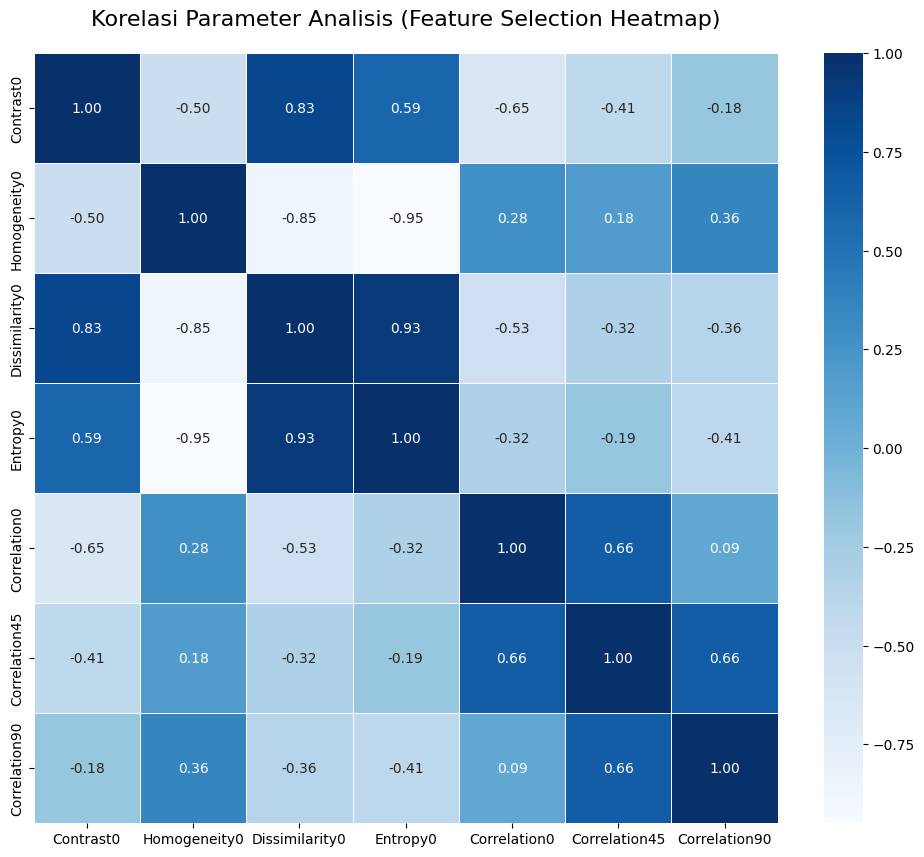

In [21]:
corr_matrix = df.drop(columns=['Label','Filename']).corr()
threshold = 0.95
columns_to_keep = np.full((corr_matrix.shape[0],), True, dtype=bool)

for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns_to_keep[j]:
                columns_to_keep[j] = False

selected_columns = df.drop(columns=['Label','Filename']).columns[columns_to_keep]
X_selected = df[selected_columns]
y = df['Label']

print(f"Dimensi fitur inisial (Pre-selection) : 28")
print(f"Dimensi fitur akhir (Post-selection) : {len(selected_columns)}")
print(f"Kumpulan variabel fitur fungsional terpilih: {list(selected_columns)}")

plt.figure(figsize=(12, 10))
sns.heatmap(X_selected.corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title('Korelasi Parameter Analisis (Feature Selection Heatmap)', fontsize=16, pad=20)
plt.show()

## 17. Data Splitting (Train & Test)

Hukum yang paling dasar di dalam membangun kemampuan sebuah kecerdasan buatan (*Machine Learning*) adalah jangan pernah mengujinya dengan contoh soal yang persis sama dengan materi latihannya. Objek penilaian murni haruslah bersifat asing.

Agar adil, kode fungsional `train_test_split` di bawah ini akan mengacak seluruh data gambar tadi dan membaginya dengan proporsi 80:20. Sebanyak 80% akan kita fungsikan eksklusif sebagai Data Latih untuk dipelajari oleh model, sedangkan porsi 20% sisanya kita kurung menjadi Data Uji (*Test Set*). Hasil cetak ukuran tabel matriks di bagian bawah memastikan kebenaran proporsi distribusi data tersebut sudah selaras.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
print(f"Distribusi dimensi Data Latih (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Distribusi dimensi Data Uji (X_test, y_test): {X_test.shape}, {y_test.shape}")

Distribusi dimensi Data Latih (X_train, y_train): (160, 7), (160,)
Distribusi dimensi Data Uji (X_test, y_test): (40, 7), (40,)


## 18. Feature Normalization (Z-Score)

Beberapa model analitik seperti *KNN* dan *SVM* biasanya akan kewalahan jika mereka menghadapi fitur data yang skala interval angkanya terlampau tidak setara (ada angka puluhan disandingkan dengan angka pecahan desimal yang sangat kecil).

Solusinya, kita ratakan skala seluruh parameter input tersebut ke dalam standarisasi yang kita sebut dengan *Z-Score Normalization*. Melalui proses ini, jarak sebaran poinnya disetarakan sedemikian rupa sehingga rata-ratanya berpusat tepat di titik 0 dengan margin standar deviasi bernilai 1. Untuk menjaga kemurnian data tes, batas angka rata-rata dihitung sepenuhnya berdasarkan Data Latih saja. Tabel di bawah sel ini mengilustrasikan wujud nyata rentang angka *DataFrame* tersebut setelah berhasil disetarakan skalanya.

In [23]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_train = (X_train - mean_train) / std_train
X_test  = (X_test  - mean_train) / std_train

print("Verifikasi hasil distribusi Z-Score Normalization (Train Data):")
display(X_train.head())

Verifikasi hasil distribusi Z-Score Normalization (Train Data):


,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,Correlation0,Correlation45,Correlation90
79,0.900160,-0.376708,0.654063,0.378107,-1.525593,-1.780379,-0.339605
197,-0.307470,0.850989,-0.922630,-0.616384,0.530448,-0.849700,-0.832467
38,1.735278,-0.882565,1.518671,1.389792,-0.352741,0.041471,0.142882
24,0.217408,0.248793,0.099284,0.060221,-0.477541,0.864270,0.813436
122,-0.619315,1.006183,-0.689545,-0.623513,0.266048,1.224177,0.927879


## 19. Inisialisasi Model Klasifikasi

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
def generateClassificationReport(y_true, y_pred, model_name):
    print(f"=== Laporan Metrik Evaluasi: {model_name} ===")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    print(f"Accuracy Score: {accuracy_score(y_true, y_pred) * 100:.2f}%\n")

rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Sebelum memulai uji tanding performa algoritmanya, kita menyiapkan cetak biru dari pengujian. Deklarasi blok fungsi `generateClassificationReport` di atas secara otomatis akan menampilkan *Classification Report* berisi nilai akurasi klasifikasinya beserta pembuatan diagram kotak *Confusion Matrix* agar proses pembacaan tebakan model jadi lebih komprehensif.

Setelah siap, kita juga memanggil tiga jenis metode algoritmik andalan untuk bersaing memprediksi hasil diagnosis, yaitu:
1. **Random Forest (rf)**: Model yang mengumpulkan kesimpulan suara terbanyak dari serangkaian cabang pohon keputusan majemuk.
2. **Support Vector Machine (svm)**: Model tangguh yang membelah area data menggunakan trik pemisah perbatasan (Kernel *RBF*), seringkali superior pada area kelompok data yang polanya rumit melengkung.
3. **K-Nearest Neighbors (knn)**: Konsep model observasi yang lebih intuitif, yang akan memprediksi suatu daun menderita jenis penyakit apa dengan merujuk kesimpulan pada 5 tetangga gambar di sekitarnya yang angkanya saling berdekatan.

## 20. Evaluasi Model Random Forest

Kita tiba pada sesi eksekusi pemodelan! Panggung evaluasi perdana dikerjakan menggunakan kerangka *Random Forest*. Di sini, kita akan menyuruh si model algoritmik untuk beradaptasi dan memahami struktur perbandingan data dengan metode `fit()`. Usai belajar mengenali pola tekstur daun yang sakit dan yang sehat, saatnya mengujinya langsung berhadapan dengan data uji (*test set*).

Laporan yang terbentuk otomatis di bawah akan secara eksplisit mencetak skor presisi evaluasinya. Kotak-kotak dari diagram *Confusion Matrix* melengkapi laporan tersebut sebagai visualisasi pembuktian: kita bisa mengetahui secara pasti sejauh mana model tersebut andal membedakan pola, dan berapa banyak jumlah kasus di mana tebakan teoretis *Random Forest* keliru meramal identitas daun tersebut.

=== Laporan Metrik Evaluasi: Random Forest ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.95      0.92        19
     daun_sehat_100       0.95      0.90      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.93      0.92        40
       weighted avg       0.93      0.93      0.93        40



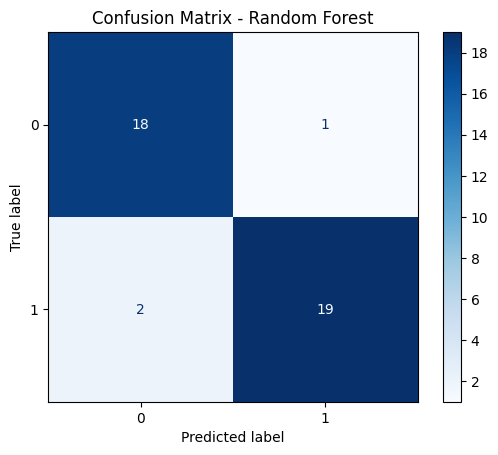

Accuracy Score: 92.50%



In [25]:
rf.fit(X_train, y_train)

prediksi_rf = rf.predict(X_test)
generateClassificationReport(y_test, prediksi_rf, "Random Forest")

## 21. Evaluasi Model Support Vector Machine

Metode uji pembanding selanjutnya mengoperasikan model Support Vector Machine (SVM). Dengan mengaplikasikan kapabilitas fungsi kernel *Radial Basis Function (RBF)*, algoritma SVM ini dirancang lebih luwes dalam memetakan tebakan, mengoptimalkan titik perbatasan kelas rumit yang seringkali sulit dipisahkan menggunakan sekadar perhitungan linier lurus semata.

Lihat pada persentase output kehandalan prediksinya yang tercetak di bawah sel ini. *Confusion Matrix* yang terlampir di sana akan segera membongkar fakta apakah stabilitas performa pemisah SVM ini sanggup menyalip kemampuan evaluasi *Random Forest* sebelumnya saat dihadapkan pada observasi sampel daun asing yang rentan salah dikelompokkan.

=== Laporan Metrik Evaluasi: Support Vector Machine ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.94      0.89      0.92        19
     daun_sehat_100       0.91      0.95      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.92      0.92        40
       weighted avg       0.93      0.93      0.92        40



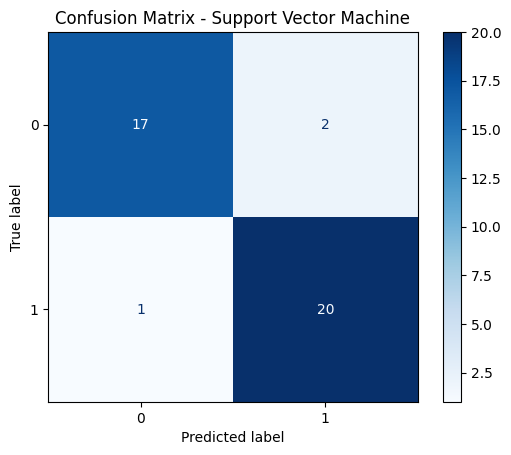

Accuracy Score: 92.50%



In [26]:
svm.fit(X_train, y_train)

prediksi_svm = svm.predict(X_test)
generateClassificationReport(y_test, prediksi_svm, "Support Vector Machine")

## 22. Evaluasi Model K-Nearest Neighbors

Sesi komparasi performa prediksi terakhir dilangsungkan melalui penerapan K-Nearest Neighbors (KNN). Kinerja prediksi dari model pemetaan kedekatan wilayah spasial ini sangat sensitif dan bergantung pada perbandingan angka jarak secara konvensional.

Tampilan skor akhir evaluasi maupun diagram persebaran positif klasifikasi yang terekam persis di bawah akan menceritakan hasil kerjanya. Bilamana tingkat akurasi presentase KNN ini tetap mampu unggul atau solid menyaingi kehandalan metode komputasi rumit seperti SVM, maka hal itu membuktikan konfirmasi bahwa tahap penyetaraan rentang fitur (*Z-Score Normalization*) yang sebelumnya kita kerjakan sukses berat memfasilitasi algoritma sederhana bekerja dengan sangat mulus

=== Laporan Metrik Evaluasi: K-Nearest Neighbors ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.94      0.89      0.92        19
     daun_sehat_100       0.91      0.95      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.92      0.92        40
       weighted avg       0.93      0.93      0.92        40



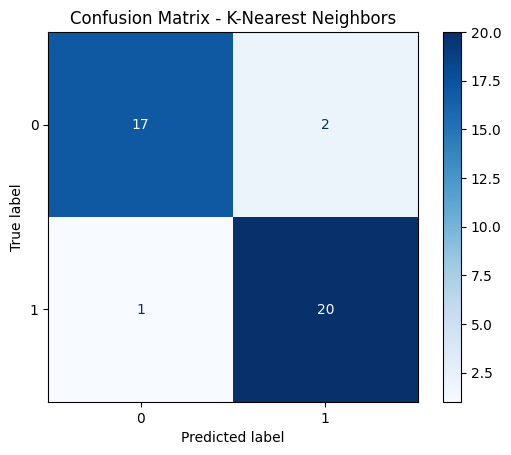

Accuracy Score: 92.50%



In [27]:
knn.fit(X_train, y_train)

prediksi_knn = knn.predict(X_test)
generateClassificationReport(y_test, prediksi_knn, "K-Nearest Neighbors")